In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_dataset.csv")

df.head()

,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [2]:
df = df.sort_values(
    ["project_id", "year"]
).reset_index(drop=True)

df[["project_id", "year", "cash_flow"]].head(15)

,project_id,year,cash_flow
0,P0001,1,-2395752.07
1,P0001,2,5588259.78
2,P0001,3,3249734.67
3,P0001,4,8667076.68
4,P0001,5,9068670.71
5,P0001,6,10906457.69
6,P0001,7,7209321.18
7,P0001,8,10192767.52
8,P0001,9,10402911.22
9,P0002,1,-2848384.67


In [3]:
sequence_features = [
    "cash_flow",
    "inflation_rate",
    "market_growth_rate"
]

In [4]:
sequence_length = 3

X_sequences = []
y_sequences = []
project_sequence_ids = []

for project_id, project in df.groupby("project_id"):

    project = project.sort_values("year")

    values = project[sequence_features].values
    cash_flows = project["cash_flow"].values

    if len(project) <= sequence_length:
        continue

    for i in range(len(project) - sequence_length):

        X_sequences.append(
            values[i:i + sequence_length]
        )

        y_sequences.append(
            cash_flows[i + sequence_length]
        )

        project_sequence_ids.append(project_id)

In [5]:
import numpy as np

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

X shape: (1765, 3, 3)
y shape: (1765,)


In [6]:
print("One input sequence:")
print(X_sequences[0])

print("\nTarget cash flow:")
print(y_sequences[0])

One input sequence:
[[-2.39575207e+06  6.00000000e-02  1.00000000e-02]
 [ 5.58825978e+06  7.00000000e-02  4.00000000e-02]
 [ 3.24973467e+06  9.00000000e-02  8.00000000e-02]]

Target cash flow:
8667076.68


In [8]:
from sklearn.model_selection import train_test_split

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

print("Training projects:", len(train_projects))
print("Testing projects:", len(test_projects))

Training projects: 400
Testing projects: 100


In [9]:
train_df = df[df["project_id"].isin(train_projects)].copy()
test_df = df[df["project_id"].isin(test_projects)].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 2620
Testing rows: 645


In [10]:
def create_sequences(data, sequence_length=3):

    X = []
    y = []
    project_ids = []

    for project_id, project in data.groupby("project_id"):

        project = project.sort_values("year")

        values = project[sequence_features].values
        cash_flows = project["cash_flow"].values

        if len(project) <= sequence_length:
            continue

        for i in range(len(project) - sequence_length):

            X.append(
                values[i:i + sequence_length]
            )

            y.append(
                cash_flows[i + sequence_length]
            )

            project_ids.append(project_id)

    return (
        np.array(X),
        np.array(y),
        np.array(project_ids)
    )

In [11]:
X_train, y_train, train_sequence_projects = create_sequences(
    train_df,
    sequence_length=3
)

X_test, y_test, test_sequence_projects = create_sequences(
    test_df,
    sequence_length=3
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1420, 3, 3)
y_train: (1420,)

X_test: (345, 3, 3)
y_test: (345,)


In [12]:
overlap = set(train_sequence_projects) & set(test_sequence_projects)

print("Project overlap:", len(overlap))

Project overlap: 0


In [13]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = X_scaler.fit_transform(X_train_2d)
X_test_scaled = X_scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

In [14]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, 1)
).ravel()

In [15]:
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled:", y_train_scaled.shape)

print("\nX_test_scaled:", X_test_scaled.shape)
print("y_test_scaled:", y_test_scaled.shape)

X_train_scaled: (1420, 3, 3)
y_train_scaled: (1420,)

X_test_scaled: (345, 3, 3)
y_test_scaled: (345,)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [18]:
model = Sequential([
    LSTM(
        32,
        input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])
    ),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\DELL 3530\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.8279 - val_loss: 0.4204
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4126 - val_loss: 0.2022
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2533 - val_loss: 0.1774
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2117 - val_loss: 0.1544
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1840 - val_loss: 0.1361
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1615 - val_loss: 0.1249
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1460 - val_loss: 0.1118
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1375 - val_loss: 0.1095
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1324 - val_loss: 0.1065
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1315 - val_loss: 0.1032
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1281 - val_loss: 0.1044
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - los

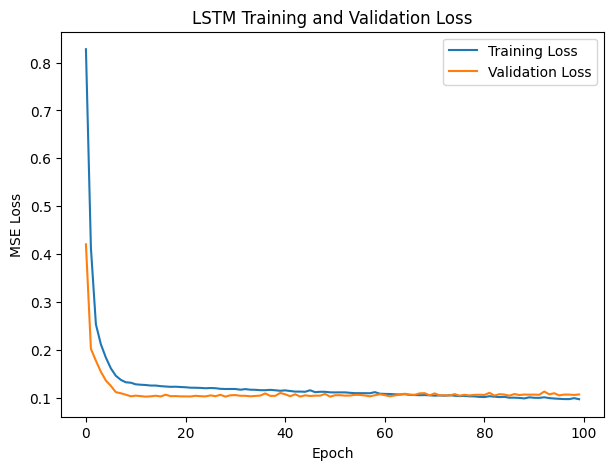

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()

plt.show()

In [21]:
y_pred_scaled = model.predict(
    X_test_scaled
).ravel()

y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("LSTM Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

LSTM Results
MAE : 2394359.3983768118
RMSE: 3448431.2482522996
R²  : 0.8583925043428287


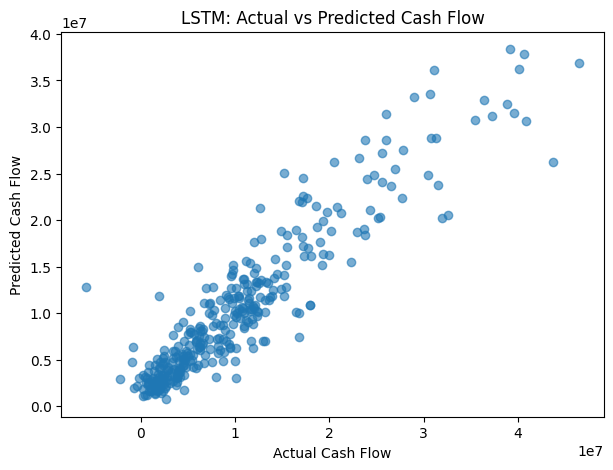

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("LSTM: Actual vs Predicted Cash Flow")

plt.show()

In [25]:
lstm_result = {
    "model": "LSTM",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

print(lstm_result)

{'model': 'LSTM', 'MAE': 2394359.3983768118, 'RMSE': np.float64(3448431.2482522996), 'R2': 0.8583925043428287}
